# 05 — Z-Score vs Min-Max Scaling

## Two normalization strategies

### Z-Score (Standardization)

$$z = \frac{x - \mu}{\sigma}$$

- Output: mean=0, std=1
- Output range: unbounded (typically −3 to +3)
- Best for: Gaussian-distributed data, linear models, neural networks
- Sensitive to outliers

### Min-Max Scaling

$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

- Output: values in [0, 1]
- Output range: strictly bounded
- Best for: algorithms that need bounded input (e.g., sigmoid activations, k-NN)
- Very sensitive to outliers (one extreme value squishes everything else)

### Reversibility

Both methods are **fully reversible** — you can get the original data back:

- Z-Score: $x = z \cdot \sigma + \mu$
- Min-Max: $x = x_{\text{scaled}} \cdot (x_{\max} - x_{\min}) + x_{\min}$

This reversibility is the core idea behind **RevIN** (notebook 08).

---

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
from utils.ml_utils import z_score_normalize, minmax_normalize, denormalize_data
from utils.plotting import plot_normalization_comparison, plot_before_after_distribution

In [2]:
df     = pd.read_csv('../data/fundamentals_data.csv')
sales  = df['sales'].values.astype(float)

## Apply both methods

In [3]:
sales_z,  params_z  = z_score_normalize(sales)
sales_mm, params_mm = minmax_normalize(sales)

print('Original  — min: {:.1f}, max: {:.1f}, mean: {:.1f}, std: {:.1f}'.format(
      sales.min(), sales.max(), sales.mean(), sales.std()))
print('Z-Score   — min: {:.3f}, max: {:.3f}, mean: {:.3f}, std: {:.3f}'.format(
      sales_z.min(), sales_z.max(), sales_z.mean(), sales_z.std()))
print('Min-Max   — min: {:.3f}, max: {:.3f}, mean: {:.3f}, std: {:.3f}'.format(
      sales_mm.min(), sales_mm.max(), sales_mm.mean(), sales_mm.std()))

Original  — min: 270.0, max: 796.0, mean: 495.3, std: 120.6
Z-Score   — min: -1.869, max: 2.494, mean: 0.000, std: 1.000
Min-Max   — min: 0.000, max: 1.000, mean: 0.428, std: 0.229


## Visualise the three distributions

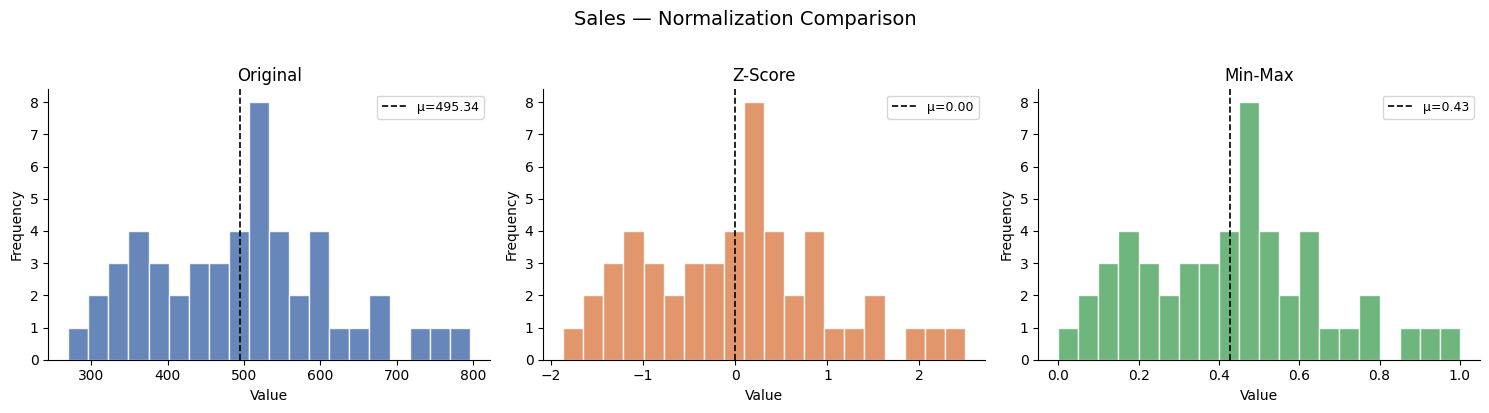

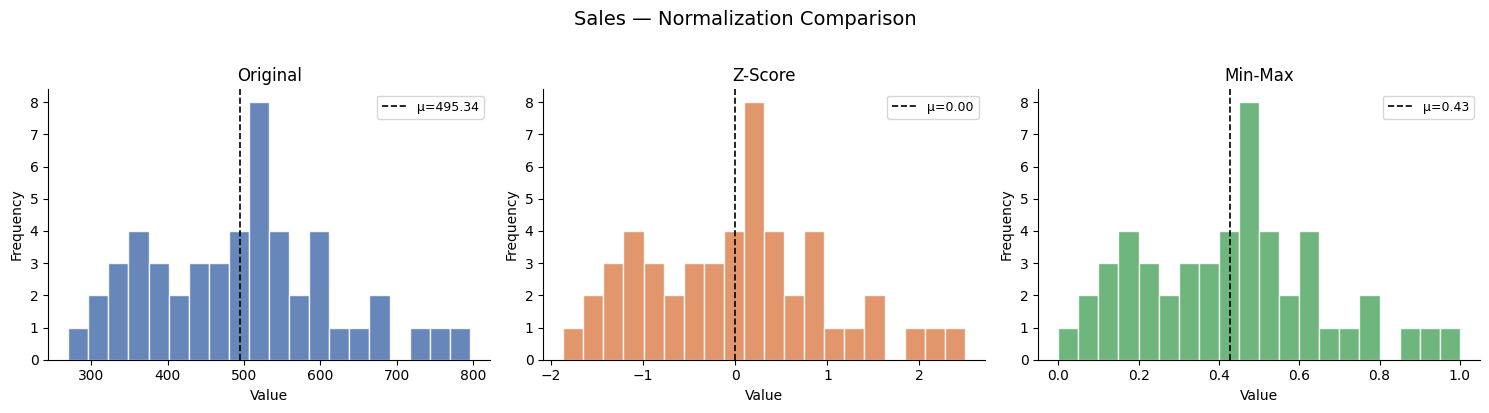

In [4]:
plot_normalization_comparison(sales, sales_z, sales_mm, title='Sales — Normalization Comparison')

## Reversibility — getting the original data back

In [7]:
sales_z_restored  = denormalize_data(sales_z,  params_z)
sales_mm_restored = denormalize_data(sales_mm, params_mm)

print('Max reconstruction error (z-score)  :', np.max(np.abs(sales - sales_z_restored)))
print('Max reconstruction error (min-max)  :', np.max(np.abs(sales - sales_mm_restored)))
print('Perfectly reversible (within float precision).')

Max reconstruction error (z-score)  : 0.0
Max reconstruction error (min-max)  : 0.0
Perfectly reversible (within float precision).


## Outlier sensitivity comparison

In [8]:
sales_with_outlier = np.append(sales, 5000)  # extreme outlier

z_out,  _ = z_score_normalize(sales_with_outlier)
mm_out, _ = minmax_normalize(sales_with_outlier)

print('Z-Score with outlier — most values in range:', 
      f'[{z_out[:-1].min():.2f}, {z_out[:-1].max():.2f}]')
print('Min-Max with outlier — most values in range:', 
      f'[{mm_out[:-1].min():.3f}, {mm_out[:-1].max():.3f}]')
print()
print('Min-Max squishes 98% of data into a tiny range because of one outlier!')

Z-Score with outlier — most values in range: [-0.49, 0.33]
Min-Max with outlier — most values in range: [0.000, 0.111]

Min-Max squishes 98% of data into a tiny range because of one outlier!


## When to use which?

| Scenario | Prefer |
|----------|--------|
| Neural networks, linear models | **Z-Score** |
| Image pixel values (0–255) | **Min-Max** |
| Data with outliers | **Z-Score** (or robust scaling) |
| Need strict [0,1] output | **Min-Max** |
| Time series windows (RevIN) | **Z-Score per instance** |

---
## Exercises

1. Apply both methods to `stock_price`. Which preserves the relative shape better?
2. Write the denormalization formula for min-max on paper, then verify with code.
3. What would happen if all values in the array were identical? (Hint: look at the
   denominator of each formula.) How does our code handle it?

---
**Next →** `06_time_series_basics.ipynb`